In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg

In [2]:
data=pd.read_csv('daily-minimum-temperatures-in-me.csv')

In [3]:
data.head()

,Date,Daily minimum temperatures
0,1/1/1981,20.7
1,1/2/1981,17.9
2,1/3/1981,18.8
3,1/4/1981,14.6
4,1/5/1981,15.8


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Date                        3650 non-null   object
 1   Daily minimum temperatures  3650 non-null   object
dtypes: object(2)
memory usage: 57.2+ KB


In [5]:
data['Date']=pd.to_datetime(data['Date'])

In [6]:
data

,Date,Daily minimum temperatures
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
...,...,...
3645,1990-12-27,14
3646,1990-12-28,13.6
3647,1990-12-29,13.5
3648,1990-12-30,15.7


In [7]:
data.set_index("Date",inplace=True)

In [8]:
data.sample(10)

,Daily minimum temperatures
Date,
1987-10-13,10
1987-02-22,10.5
1988-02-17,13.6
1989-05-12,12.7
1983-02-09,17.2
1982-10-16,9.8
1982-03-01,11.9
1986-05-01,11.1
1989-02-12,15.2


In [9]:
data.head()

,Daily minimum temperatures
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8
1981-01-04,14.6
1981-01-05,15.8


In [10]:
data.tail()

,Daily minimum temperatures
Date,
1990-12-27,14
1990-12-28,13.6
1990-12-29,13.5
1990-12-30,15.7
1990-12-31,13


In [11]:
data.isnull().sum()

Daily minimum temperatures    0
dtype: int64

In [12]:
rows = data[
    data['Daily minimum temperatures'].astype(str).str.contains(r'\?', na=False)
]

In [13]:
rows

,Daily minimum temperatures
Date,
1982-07-20,?0.2
1982-07-21,?0.8
1984-07-14,?0.1


In [14]:
data['Daily minimum temperatures']=data['Daily minimum temperatures'].str.replace("?","")

In [15]:
data['Daily minimum temperatures']=data['Daily minimum temperatures'].astype('float')

In [16]:
data.dtypes

Daily minimum temperatures    float64
dtype: object

In [17]:
rows = data[
    data['Daily minimum temperatures'].astype(str).str.contains(r'\?', na=False)
]

In [18]:
rows

,Daily minimum temperatures
Date,


<Axes: xlabel='Date'>

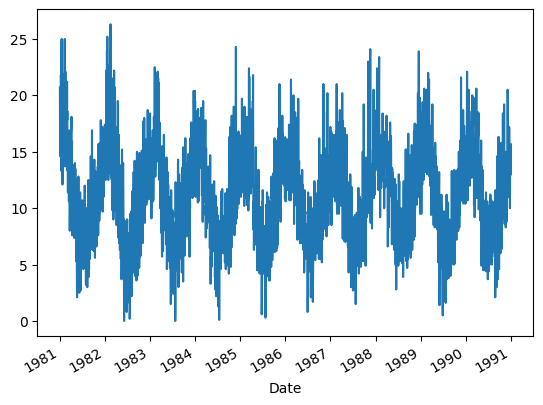

In [19]:
data['Daily minimum temperatures'].plot()

<Axes: xlabel='Date'>

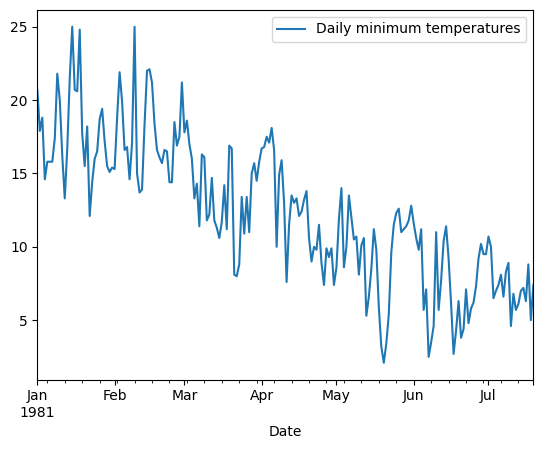

In [20]:
data[:200].plot()

In [21]:
from statsmodels.tsa.stattools import adfuller,kpss

In [22]:
def adf_test(series):
    adf_test=adfuller(series)
    print(f"adf stats:{round(adf_test[0],3)}")
    print(f"p-value stats:{round(adf_test[1],3)}")
    print(f"lags values:{round(adf_test[2],3)}")
    for key,value in adf_test[4].items():
     print(f"{key}:{round(value,3)}")
        
def kpss_test(series):
    kpss_test=kpss(series,regression='ct')
    print("KPSS Statistic:", kpss_test[0])
    print("p-value:", kpss_test[1])
    print("Lags used:", kpss_test[2])
    print("Critical values:", kpss_test[3].items())
    

In [23]:
adf_test(data['Daily minimum temperatures'])

adf stats:-4.445
p-value stats:0.0
lags values:20
1%:-3.432
5%:-2.862
10%:-2.567


In [24]:
kpss_test(data['Daily minimum temperatures'])

KPSS Statistic: 0.049232800518522864
p-value: 0.1
Lags used: 36
Critical values: dict_items([('10%', 0.119), ('5%', 0.146), ('2.5%', 0.176), ('1%', 0.216)])


C:\Users\Mcc\AppData\Local\Temp\ipykernel_11684\3642343553.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_test=kpss(series,regression='ct')


In [107]:
#p<0.05 means data has stationarity adf test
#p>0.05 in kpss means stationaruty

In [25]:
from scipy import stats
from scipy.stats import ks_2samp

In [26]:
len(data)

3650

In [27]:
# now check for distribution of data same or different
first_half=data['Daily minimum temperatures'].iloc[:len(data)//2]
second_half=data['Daily minimum temperatures'].iloc[len(data)//2:]

In [28]:
stat, p = ks_2samp(first_half, second_half)

In [29]:
stat

np.float64(0.052054794520547946)

In [30]:
if p<0.05:
    print("Distributions are significantly different")
else:
    print("No significant evidence that distributions differ")

Distributions are significantly different


In [31]:
p

np.float64(0.014222387518487985)

In [32]:
#but the value 0.007 is not significatly enough to to support null hypothesis

In [33]:
from statsmodels.graphics.tsaplots import plot_pacf,plot_acf

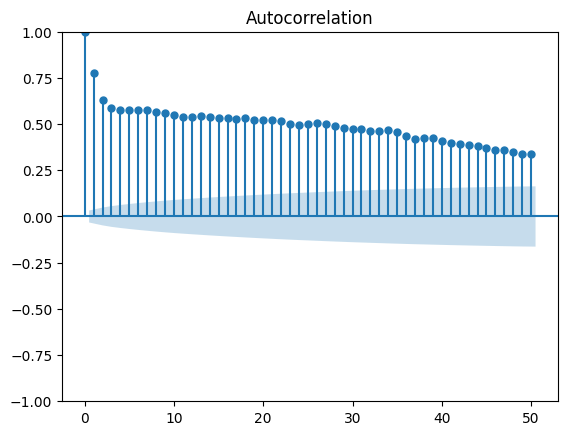

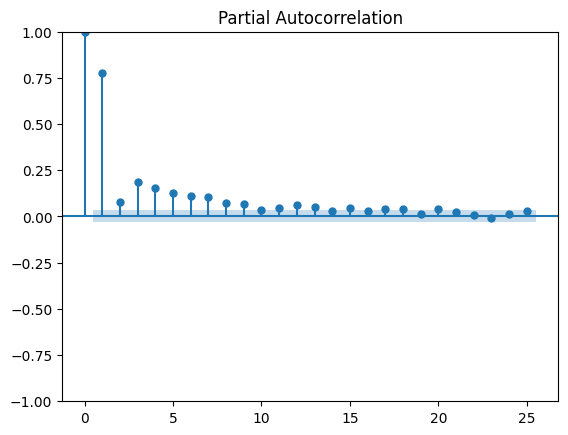

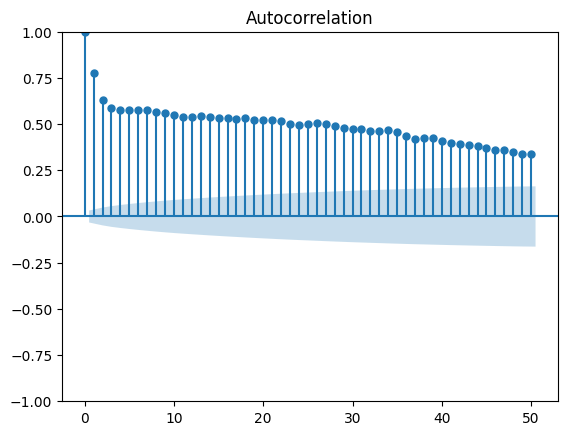

In [34]:
plot_pacf(data['Daily minimum temperatures'],lags=25)
plot_acf(data['Daily minimum temperatures'],lags=50)

In [118]:
# for AR model we check pacf here we can show that order of ar model is about 8-10 which AR(P), AR(8-10) means we 
# have to  use lags between =8-10 is significant good

In [35]:
train=data['Daily minimum temperatures'].iloc[:-7]
test=data['Daily minimum temperatures'].iloc[-7:]

In [36]:
train.shape,test.shape

((3643,), (7,))

In [37]:
model=AutoReg(train,lags=10).fit()

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [38]:
print(model.summary())

                                AutoReg Model Results                                 
Dep. Variable:     Daily minimum temperatures   No. Observations:                 3643
Model:                            AutoReg(10)   Log Likelihood               -8375.514
Method:                       Conditional MLE   S.D. of innovations              2.427
Date:                        Thu, 27 Aug 2026   AIC                          16775.028
Time:                                22:01:06   BIC                          16849.402
Sample:                                    10   HQIC                         16801.521
                                         3643                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const                              0.9350      0.142      6.603      0.000       0.657       1.213
Daily m

In [39]:
pred=model.predict(start=len(train),end=len(data)-1,dynamic=False)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [40]:
len(train),len(data)

(3643, 3650)

In [41]:
pred.index = test.index

In [42]:
pred

Date
1990-12-25    11.476793
1990-12-26    12.637266
1990-12-27    13.057466
1990-12-28    13.033789
1990-12-29    12.825931
1990-12-30    12.657672
1990-12-31    12.432736
dtype: float64

In [43]:
test

Date
1990-12-25    12.9
1990-12-26    14.6
1990-12-27    14.0
1990-12-28    13.6
1990-12-29    13.5
1990-12-30    15.7
1990-12-31    13.0
Name: Daily minimum temperatures, dtype: float64

In [44]:
import matplotlib.pyplot as plt


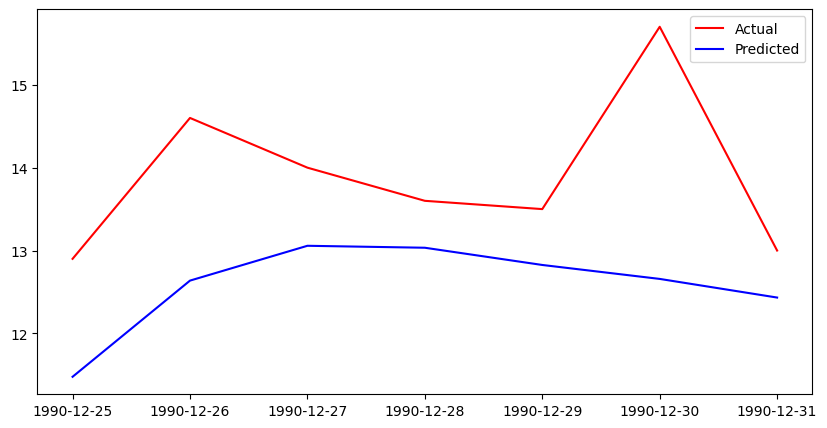

In [45]:
plt.figure(figsize=(10, 5))

plt.plot(test.index, test,
         color='red', label='Actual')

plt.plot(pred.index, pred,
         color='blue', label='Predicted')

plt.legend()
plt.show()

In [46]:
from math import sqrt

In [47]:
from sklearn.metrics import mean_squared_error

In [48]:
rmse=sqrt(mean_squared_error(test,pred))

In [49]:
rmse

1.5638196220860905

In [194]:
#make future predictions

In [50]:
pred_future=model.predict(start=len(data),end=len(data)+6,dynamic=False)

C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\Mcc\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [51]:
pred_future

3650    12.366710
3651    12.286088
3652    12.203095
3653    12.249159
3654    12.306189
3655    12.311997
3656    12.272260
dtype: float64

In [200]:
pred_future.index = pd.date_range(
    start=data.index[-1] + pd.Timedelta(days=1),
    periods=7,
    freq='D'
)

In [201]:
pred_future

1991-01-01    12.366710
1991-01-02    12.286088
1991-01-03    12.203095
1991-01-04    12.249159
1991-01-05    12.306189
1991-01-06    12.311997
1991-01-07    12.272260
Freq: D, dtype: float64